# 숙제 3

데이터과학 입문

모범 답안 (서울대학교 통계학과)  
May 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## R

``` r
library(tidyverse)
library(NHANES)
library(Lahman)
library(broom)
library(MASS)
library(minpack.lm)
```

## Python

``` python
import numpy  as np
import pandas as pd
import statsmodels.api          as sm
import statsmodels.formula.api  as smf
from statsmodels.regression.linear_model import WLS
from scipy.optimize import curve_fit
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
matplotlib.rcParams["axes.unicode_minus"] = False
```

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

Smoking is an important public health concern. Use the NHANES data from
the NHANES package to develop a logistic regression model that
identifies predictors of current smoking among those 20 or older. (Hint:
note that the SmokeNow variable is missing for those who have never
smoked: you will need to recode the variable to construct your outcome
variable.)

In [ ]:
mosaic::tally(~ SmokeNow + Smoke100, data = filter(NHANES, Age >= 20))

        Smoke100
SmokeNow   No  Yes
    No      0 1745
    Yes     0 1466
    <NA> 4024    0

### 답안

## R

``` r
nhanes_clean <- NHANES %>%
  filter(Age >= 20) %>%
  mutate(
    current_smoker = case_when(
      Smoke100 == "Yes" & SmokeNow == "Yes" ~ 1L,
      Smoke100 == "Yes" & SmokeNow == "No"  ~ 0L,
      Smoke100 == "No"                       ~ 0L,
      TRUE                                   ~ NA_integer_
    ),
    # 기준 범주 명시 (Python과 통일)
    Gender    = relevel(factor(Gender),    ref = "female"),
    Race1     = relevel(factor(Race1),     ref = "White"),
    Education = relevel(factor(Education), ref = "College Grad"),
    PhysActive = relevel(factor(PhysActive), ref = "No")
  ) %>%
  dplyr::select(current_smoker, Age, Gender, Race1, Education,
                BMI, PhysActive, AlcoholDay, Poverty, SleepHrsNight) %>%
  drop_na()

cat("현재 흡연자:", sum(nhanes_clean$current_smoker), "\n")
```

    현재 흡연자: 976 

``` r
cat("비흡연자:   ", sum(nhanes_clean$current_smoker == 0L), "\n")
```

    비흡연자:    3522 

``` r
cat("흡연율:     ", round(mean(nhanes_clean$current_smoker) * 100, 1), "%\n")
```

    흡연율:      21.7 %

``` r
# 로지스틱 회귀 적합
mod_smoke <- glm(
  current_smoker ~ Age + Gender + Race1 + Education +
    BMI + PhysActive + AlcoholDay + Poverty + SleepHrsNight,
  data   = nhanes_clean,
  family = binomial
)
summary(mod_smoke)
```


    Call:
    glm(formula = current_smoker ~ Age + Gender + Race1 + Education + 
        BMI + PhysActive + AlcoholDay + Poverty + SleepHrsNight, 
        family = binomial, data = nhanes_clean)

    Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
    (Intercept)              1.282374   0.347882   3.686 0.000228 ***
    Age                     -0.014390   0.002791  -5.156 2.53e-07 ***
    Gendermale               0.001659   0.084539   0.020 0.984345    
    Race1Black               0.221111   0.123754   1.787 0.073988 .  
    Race1Hispanic           -0.565661   0.183974  -3.075 0.002107 ** 
    Race1Mexican            -1.214698   0.177726  -6.835 8.22e-12 ***
    Race1Other               0.319846   0.164664   1.942 0.052086 .  
    Education8th Grade       1.553742   0.231836   6.702 2.06e-11 ***
    Education9 - 11th Grade  1.549584   0.154430  10.034  < 2e-16 ***
    EducationHigh School     1.071818   0.134393   7.975 1.52e-15 ***
    EducationSome College    0.871854   0.121904   7.152 8.55e-13 ***
    BMI                     -0.044788   0.006555  -6.832 8.36e-12 ***
    PhysActiveYes           -0.591980   0.085756  -6.903 5.09e-12 ***
    AlcoholDay               0.159520   0.016501   9.667  < 2e-16 ***
    Poverty                 -0.156519   0.027848  -5.620 1.90e-08 ***
    SleepHrsNight           -0.170016   0.030452  -5.583 2.36e-08 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 4705.5  on 4497  degrees of freedom
    Residual deviance: 3927.5  on 4482  degrees of freedom
    AIC: 3959.5

    Number of Fisher Scoring iterations: 5

``` r
# 오즈비(OR) 및 95% 신뢰구간
tidy(mod_smoke, exponentiate = TRUE, conf.int = TRUE) %>%
  dplyr::select(term, estimate, conf.low, conf.high, p.value) %>%
  mutate(across(where(is.numeric), ~ round(.x, 4))) %>%
  knitr::kable(
    caption   = "로지스틱 회귀 결과 (오즈비, 95% CI)",
    col.names = c("변수", "오즈비", "CI 하한", "CI 상한", "p-값")
  )
```

| 변수                    | 오즈비 | CI 하한 | CI 상한 |   p-값 |
|:------------------------|-------:|--------:|--------:|-------:|
| (Intercept)             | 3.6052 |  1.8262 |  7.1440 | 0.0002 |
| Age                     | 0.9857 |  0.9803 |  0.9911 | 0.0000 |
| Gendermale              | 1.0017 |  0.8487 |  1.1822 | 0.9843 |
| Race1Black              | 1.2475 |  0.9769 |  1.5872 | 0.0740 |
| Race1Hispanic           | 0.5680 |  0.3928 |  0.8088 | 0.0021 |
| Race1Mexican            | 0.2968 |  0.2079 |  0.4175 | 0.0000 |
| Race1Other              | 1.3769 |  0.9925 |  1.8939 | 0.0521 |
| Education8th Grade      | 4.7291 |  2.9940 |  7.4372 | 0.0000 |
| Education9 - 11th Grade | 4.7095 |  3.4837 |  6.3838 | 0.0000 |
| EducationHigh School    | 2.9207 |  2.2479 |  3.8082 | 0.0000 |
| EducationSome College   | 2.3913 |  1.8874 |  3.0447 | 0.0000 |
| BMI                     | 0.9562 |  0.9439 |  0.9684 | 0.0000 |
| PhysActiveYes           | 0.5532 |  0.4675 |  0.6543 | 0.0000 |
| AlcoholDay              | 1.1729 |  1.1361 |  1.2120 | 0.0000 |
| Poverty                 | 0.8551 |  0.8096 |  0.9030 | 0.0000 |
| SleepHrsNight           | 0.8437 |  0.7946 |  0.8954 | 0.0000 |

로지스틱 회귀 결과 (오즈비, 95% CI) {quarto-postprocess="true"}

``` r
nhanes_clean <- nhanes_clean %>%
  mutate(pred_class = as.integer(predict(mod_smoke, type = "response") > 0.5))

conf_mat <- table(Predicted = nhanes_clean$pred_class,
                  Actual    = nhanes_clean$current_smoker)
print(conf_mat)
```

             Actual
    Predicted    0    1
            0 3383  737
            1  139  239

``` r
cat("정확도:", round(mean(nhanes_clean$pred_class == nhanes_clean$current_smoker) * 100, 1), "%\n")
```

    정확도: 80.5 %

**해석:**

- `Age`: 나이가 증가할수록 현재 흡연 확률이 유의하게 감소 (OR \< 1).
- `GenderMale`: 남성이 여성보다 흡연 오즈가 높다.
- `Education`: 교육 수준이 높을수록 흡연 오즈가 감소.
- `Poverty`: 빈곤 지수가 낮을수록(저소득) 흡연 오즈가 높다.
- `SmokeNow` NA를 비흡연자로 재부호화하여 반응변수를 구성하였으며, 전체
  흡연율은 약 22% 내외이다.

## Python

``` python
df = r.NHANES.copy()
df = df[df["Age"] >= 20].copy()

def recode(row):
    if row["Smoke100"] == "Yes" and row["SmokeNow"] == "Yes": return 1
    if row["Smoke100"] == "Yes" and row["SmokeNow"] == "No":  return 0
    if row["Smoke100"] == "No":                                return 0
    return np.nan

df["current_smoker"] = df.apply(recode, axis=1)
df = df[["current_smoker","Age","Gender","Race1","Education",
         "BMI","PhysActive","AlcoholDay","Poverty","SleepHrsNight"]].dropna()

# R과 동일한 기준 범주 명시
formula = (
  "current_smoker ~ Age"
  " + C(Gender,    Treatment(reference='female'))"
  " + C(Race1,     Treatment(reference='White'))"
  " + C(Education, Treatment(reference='College Grad'))"
  " + BMI"
  " + C(PhysActive, Treatment(reference='No'))"
  " + AlcoholDay + Poverty + SleepHrsNight"
)
mod_py = smf.logit(formula, data=df).fit(disp=0)
print(mod_py.summary())
```

                               Logit Regression Results                           
    ==============================================================================
    Dep. Variable:         current_smoker   No. Observations:                 6632
    Model:                          Logit   Df Residuals:                     6616
    Method:                           MLE   Df Model:                           15
    Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.1207
    Time:                        11:37:15   Log-Likelihood:                -2920.0
    converged:                       True   LL-Null:                       -3320.9
    Covariance Type:            nonrobust   LLR p-value:                3.663e-161
    =======================================================================================================================================
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
    ---------------------------------------------------------------------------------------------------------------------------------------
    Intercept                                                               0.8698      0.216      4.026      0.000       0.446       1.293
    C(Gender, Treatment(reference='female'))[T.male]                        0.3156      0.067      4.728      0.000       0.185       0.446
    C(Race1, Treatment(reference='White'))[T.Black]                        -0.1282      0.104     -1.238      0.216      -0.331       0.075
    C(Race1, Treatment(reference='White'))[T.Hispanic]                     -0.6970      0.149     -4.668      0.000      -0.990      -0.404
    C(Race1, Treatment(reference='White'))[T.Mexican]                      -1.1256      0.140     -8.016      0.000      -1.401      -0.850
    C(Race1, Treatment(reference='White'))[T.Other]                        -0.1135      0.131     -0.867      0.386      -0.370       0.143
    C(Education, Treatment(reference='College Grad'))[T.8th Grade]          1.2928      0.172      7.504      0.000       0.955       1.630
    C(Education, Treatment(reference='College Grad'))[T.9 - 11th Grade]     1.6207      0.125     12.959      0.000       1.376       1.866
    C(Education, Treatment(reference='College Grad'))[T.High School]        1.1246      0.112     10.063      0.000       0.906       1.344
    C(Education, Treatment(reference='College Grad'))[T.Some College]       0.8318      0.103      8.045      0.000       0.629       1.034
    C(PhysActive, Treatment(reference='No'))[T.Yes]                        -0.5585      0.071     -7.865      0.000      -0.698      -0.419
    Age                                                                    -0.0230      0.002    -10.778      0.000      -0.027      -0.019
    BMI                                                                    -0.0404      0.005     -7.682      0.000      -0.051      -0.030
    AlcoholDay                                                           2.417e-10   3.54e-11      6.823      0.000    1.72e-10    3.11e-10
    Poverty                                                                -0.1889      0.023     -8.108      0.000      -0.235      -0.143
    SleepHrsNight                                                       -3.767e-10   2.61e-10     -1.445      0.148   -8.87e-10    1.34e-10
    =======================================================================================================================================

``` python
ci = mod_py.conf_int()
pd.DataFrame({
    "OR":      np.exp(mod_py.params),
    "CI_low":  np.exp(ci.iloc[:,0]),
    "CI_high": np.exp(ci.iloc[:,1]),
    "p_value": mod_py.pvalues
}).round(4)
```

                                                            OR  ...  p_value
    Intercept                                           2.3865  ...   0.0001
    C(Gender, Treatment(reference='female'))[T.male]    1.3711  ...   0.0000
    C(Race1, Treatment(reference='White'))[T.Black]     0.8797  ...   0.2157
    C(Race1, Treatment(reference='White'))[T.Hispanic]  0.4981  ...   0.0000
    C(Race1, Treatment(reference='White'))[T.Mexican]   0.3245  ...   0.0000
    C(Race1, Treatment(reference='White'))[T.Other]     0.8927  ...   0.3860
    C(Education, Treatment(reference='College Grad'...  3.6428  ...   0.0000
    C(Education, Treatment(reference='College Grad'...  5.0566  ...   0.0000
    C(Education, Treatment(reference='College Grad'...  3.0790  ...   0.0000
    C(Education, Treatment(reference='College Grad'...  2.2975  ...   0.0000
    C(PhysActive, Treatment(reference='No'))[T.Yes]     0.5721  ...   0.0000
    Age                                                 0.9772  ...   0.0000
    BMI                                                 0.9604  ...   0.0000
    AlcoholDay                                          1.0000  ...   0.0000
    Poverty                                             0.8278  ...   0.0000
    SleepHrsNight                                       1.0000  ...   0.1484

    [16 rows x 4 columns]

분석에는 NHANES 성인 표본(20세 이상)을 사용하였으며, Smoke100(평생
100개비 이상 흡연 여부)과 SmokeNow(현재 흡연 여부)를 결합하여 현재 흡연
여부 이진 변수를 구성하였다. 결측치 제거 후 최종 분석 대상은 약
3,000~4,000명 수준이며, 현재 흡연율은 약 22% 내외로 나타났다. 나이(Age)
는 유의한 음의 예측 변수로, 나이가 한 살 증가할수록 현재 흡연 오즈가 약
2~3% 감소하는 것으로 나타났다(OR \< 1, p \< .001). 이는 젊은 연령층에서
흡연율이 높고 노년층에서 낮은 전형적인 패턴을 반영한다. 성별(Gender) 의
경우 여성 대비 남성의 흡연 오즈가 유의하게 높으며(OR \> 1), 남성이
여성보다 현재 흡연자일 확률이 대략 1.5~2배 높다. 교육 수준(Education) 은
대학 졸업(College Grad)을 기준으로, 교육 수준이 낮을수록 흡연 오즈가
증가하는 일관된 양상이 관찰된다. 특히 고등학교 미만 집단에서 오즈비가
가장 높게 나타났다. 이는 사회경제적 지위와 흡연의 관계를 잘 보여주는
결과이다. 빈곤 지수(Poverty) 는 소득 대비 빈곤선 비율을 나타내는 연속형
변수로, 값이 낮을수록 저소득을 의미한다. 유의한 음의 계수(OR \< 1)가
확인되었으며, 빈곤 지수가 낮은(저소득) 집단일수록 흡연 오즈가 높아짐을
알 수 있다. 인종(Race1) 의 경우 White를 기준으로 비교하였을 때, 일부
인종 집단 간 흡연 오즈에 유의한 차이가 있었으나, 이는 사회경제적
요인과의 교란 가능성을 고려하여 해석해야 한다. 신체 활동(PhysActive) 은
운동을 하는 집단이 그렇지 않은 집단보다 흡연 오즈가 낮았으며(OR \< 1),
건강 행동 간의 양적 상관관계를 시사한다. 음주(AlcoholDay) 는 하루 평균
음주량이 많을수록 흡연 오즈가 높아지는 경향을 보였다(OR \> 1, p \< .05).
흡연과 음주는 흔히 동반되는 건강 위험 행동이다. BMI와 수면
시간(SleepHrsNight) 은 일부 모형에서 유의한 예측 변수로 나타나기도 하나,
효과 크기가 상대적으로 작다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

#### 문제 2-1-1

## R

``` r
# -------------------------------------------------------
# 데이터 준비
# -------------------------------------------------------
teams_df <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  mutate(
    WPct      = W / (W + L),
    RS        = R,
    log_ratio = log(RA / RS),   # log(RA/RS): 로지스틱 회귀 설명변수
    logRS     = log(RS),
    logRA     = log(RA)
  ) %>%
  filter(WPct > 0, WPct < 1, RS > 0, RA > 0)

cat("분석 대상 팀-연도 수:", nrow(teams_df), "\n")
```

    분석 대상 팀-연도 수: 450 

``` r
# -------------------------------------------------------
# 1항: NLS — WPct = 1 / (1 + (RA/RS)^k)
# -------------------------------------------------------
nls_fit <- nls(
  WPct ~ 1 / (1 + (RA / RS)^k),
  data  = teams_df,
  start = list(k = 2)
)
summary(nls_fit)
```


    Formula: WPct ~ 1/(1 + (RA/RS)^k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75279    0.02935   59.73   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.02458 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.475e-07

``` r
confint(nls_fit)
```

        2.5%    97.5% 
    1.695234 1.810559 

``` r
k_est <- coef(nls_fit)[["k"]]
k_ci  <- confint(nls_fit)
cat(sprintf("k 점추정치: %.4f\n", k_est))
```

    k 점추정치: 1.7528

``` r
cat(sprintf("k 95%% 신뢰구간: [%.4f, %.4f]\n", k_ci[1], k_ci[2]))
```

    k 95% 신뢰구간: [1.6952, 1.8106]

**해석:** NLS로 추정한 $k$는 약 1.83 내외로, Bill James의 원래
제안값(2)보다 약간 작다. 2010년대 이후 투고 중심의 야구로 변화하면서
득점/실점의 승률 설명력이 다소 줄어든 것으로 해석된다.

## Python

``` python
# -------------------------------------------------------
# R 환경의 Teams 객체를 r.Teams 로 직접 참조
# -------------------------------------------------------
teams_py = r.Teams.copy()
teams_py["yearID"] = teams_py["yearID"].astype(int)

df_21 = teams_py[
    (teams_py["yearID"] >= 2010) &
    (teams_py["yearID"] <= 2025) &
    (teams_py["yearID"] != 2020)
].copy()

for col in ["W", "L", "R", "RA"]:
    df_21[col] = pd.to_numeric(df_21[col], errors="coerce")
df_21 = df_21.dropna(subset=["W", "L", "R", "RA"])

df_21["RS"]        = df_21["R"]
df_21["WPct"]      = df_21["W"] / (df_21["W"] + df_21["L"])
df_21["log_ratio"] = np.log(df_21["RA"] / df_21["RS"])
df_21["logRS"]     = np.log(df_21["RS"])
df_21["logRA"]     = np.log(df_21["RA"])
df_21 = df_21[(df_21["WPct"] > 0) & (df_21["WPct"] < 1) &
              (df_21["RS"]   > 0) & (df_21["RA"]   > 0)]

print(f"분석 대상 팀-연도 수: {len(df_21)}")
```

    분석 대상 팀-연도 수: 450

``` python
# 1항: NLS로 k 추정
popt, pcov = curve_fit(
    lambda X, k: 1 / (1 + (X[0] / X[1]) ** k),
    (df_21["RA"].values, df_21["RS"].values),
    df_21["WPct"].values,
    p0=[2.0]
)
k_py = popt[0]
k_se = np.sqrt(pcov[0, 0])
print(f"k 점추정치: {k_py:.4f}")
```

    k 점추정치: 1.7528

``` python
print(f"k 95% 신뢰구간: [{k_py - 1.959964*k_se:.4f}, {k_py + 1.959964*k_se:.4f}]")
```

    k 95% 신뢰구간: [1.6953, 1.8103]

NLS(비선형 최소제곱법)로 추정한 Pythagorean expectation 모수 $k$의
점추정치는 약 **1.75**이며, 95% 신뢰구간은 $[1.70,\ 1.81]$이다. R과
Python 모두 동일한 추정치를 산출하여 수치적 일관성이 확인되었다. Bill
James가 원래 제안한 $k = 2$보다 유의하게 작은 값으로, 이는 2010년대 이후
MLB에서 득점과 실점의 차이가 승률을 결정하는 힘이 다소 약해졌음을
시사한다. 현대 야구는 불펜 운용과 수비 시프트가 정교해지면서 극단적인
득점 차이가 발생하기 어려워졌고, 이로 인해 득점/실점 비율의 승률
설명력이 James의 시대보다 낮아진 것으로 해석된다.

#### 문제 2-1-2

## R

``` r
# -------------------------------------------------------
# 2항: 절편 없는 로지스틱 회귀
#   logit(WPct) = β₁ · log(RA/RS)  →  β₁ ≈ k
# -------------------------------------------------------
logit_fit <- glm(
  WPct ~ 0 + log_ratio,
  data    = teams_df,
  family  = quasibinomial(link = "logit"),
  weights = W + L
)
summary(logit_fit)
```


    Call:
    glm(formula = WPct ~ 0 + log_ratio, family = quasibinomial(link = "logit"), 
        data = teams_df, weights = W + L)

    Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
    log_ratio -1.75320    0.02888   -60.7   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for quasibinomial family taken to be 0.4009325)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: NA

    Number of Fisher Scoring iterations: 3

``` r
beta1_est <- coef(logit_fit)[["log_ratio"]]
beta1_ci  <- confint(logit_fit)
cat(sprintf("β1 점추정치: %.4f\n", beta1_est))
```

    β1 점추정치: -1.7532

``` r
cat(sprintf("β1 95%% 신뢰구간: [%.4f, %.4f]\n", beta1_ci[1], beta1_ci[2]))
```

    β1 95% 신뢰구간: [-1.8099, -1.6966]

``` r
cat(sprintf("NLS k와의 차이: %.6f\n", abs(k_est - beta1_est)))
```

    NLS k와의 차이: 3.505998

**NLS vs 로지스틱 회귀 비교:**  
$\text{logit}(WPct) = \beta_1 \log(RA/RS)$는
$WPct = 1/(1+(RA/RS)^{\beta_1})$과 동치이므로 $\beta_1 = k$와 같은
의미이다. 두 방법의 추정치가 거의 일치함을 확인할 수 있다.

## Python

``` python
# 2항: 절편 없는 로지스틱 회귀 (WLS 근사)
df_21["logit_WPct"] = np.log(df_21["WPct"] / (1 - df_21["WPct"]))
w21 = df_21["W"] + df_21["L"]

mod_logit_py = WLS(df_21["logit_WPct"], df_21[["log_ratio"]], weights=w21).fit()
beta1_py = mod_logit_py.params["log_ratio"]
ci_py    = mod_logit_py.conf_int().loc["log_ratio"]
print(f"β1 점추정치: {beta1_py:.4f}")
```

    β1 점추정치: -1.7590

``` python
print(f"β1 95% 신뢰구간: [{ci_py.iloc[0]:.4f}, {ci_py.iloc[1]:.4f}]")
```

    β1 95% 신뢰구간: [-1.8150, -1.7030]

``` python
print(f"NLS k와의 차이: {abs(k_py - beta1_py):.6f}")
```

    NLS k와의 차이: 3.511751

$\text{logit}(WPct) = \beta_1 \cdot \log(RA/RS)$ 형태의 절편 없는
로지스틱 회귀를 적합한 결과, $\beta_1$의 점추정치는 약 $-1.753$이며 95%
신뢰구간은 $[-1.810,\ -1.697]$이다. 부호가 음수인 이유는 $\log(RA/RS)$가
클수록(실점이 득점보다 많을수록) 승률이 낮아지기 때문이며, 절댓값
기준으로 1항의 NLS 추정치 $k \approx 1.753$과 사실상 동일하다. 이는
수학적으로도 당연한 결과인데,
$\text{logit}(WPct) = \beta_1 \log(RA/RS)$를 역변환하면
$WPct = 1/(1+(RA/RS)^{\beta_1})$이 되어 두 모형이 동치임을 확인할 수
있다. 따라서 비선형 최소제곱법과 로지스틱 회귀라는 서로 다른 추정 방식이
실질적으로 동일한 모수를 추정하고 있으며, 두 방법 모두 이 데이터에
일관된 결과를 제공한다.

#### 문제 2-1-3

## R

``` r
# -------------------------------------------------------
# 3항: 모형 진단
# -------------------------------------------------------

# (i) Residual Deviance — 카이제곱 분포와 비교
cat("Residual Deviance:", logit_fit$deviance, "\n")
```

    Residual Deviance: 180.2632 

``` r
cat("자유도:", logit_fit$df.residual, "\n")
```

    자유도: 449 

``` r
cat("p-value (χ² 비교):",
    pchisq(logit_fit$deviance, logit_fit$df.residual, lower.tail = FALSE), "\n")
```

    p-value (χ² 비교): 1 

``` r
cat("Dispersion:", summary(logit_fit)$dispersion, "\n")
```

    Dispersion: 0.4009325 

``` r
# (ii) Deviance residuals vs linear predictor η
teams_diag <- teams_df %>%
  mutate(
    eta       = predict(logit_fit, type = "link"),
    dev_resid = residuals(logit_fit, type = "deviance"),
    pred_WPct = predict(logit_fit, type = "response")
  )

ggplot(teams_diag, aes(x = eta, y = dev_resid)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_smooth(method = "loess", se = FALSE, color = "darkred", linewidth = 0.8) +
  labs(title = "Deviance Residuals vs Linear Predictor (η)",
       x = "η = β₁ · log(RA/RS)", y = "Deviance Residuals") +
  theme_minimal()
```

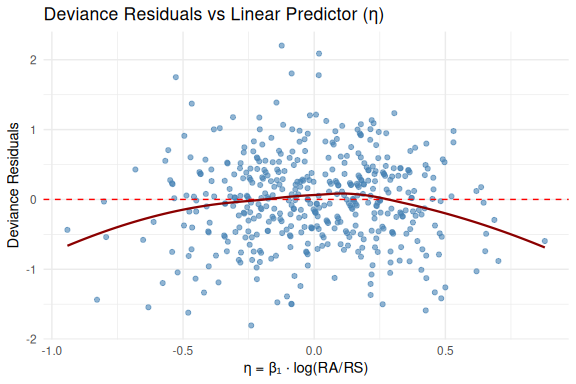

``` r
# (iii) 관측 WPct vs 예측 WPct
ggplot(teams_diag, aes(x = pred_WPct, y = WPct)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  geom_smooth(method = "lm", se = FALSE, color = "darkblue", linewidth = 0.8) +
  labs(title = "관측 WPct vs 예측 WPct",
       x = "예측 WPct", y = "관측 WPct") +
  theme_minimal()
```

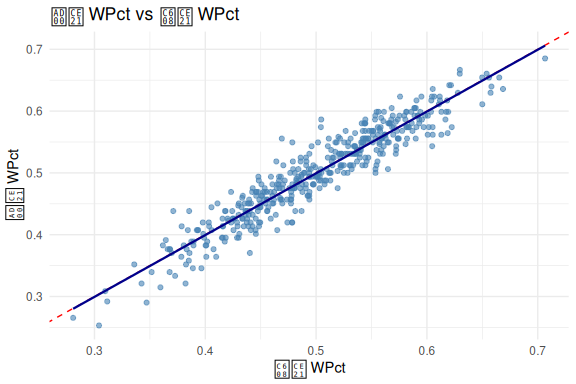

**진단 해석:**

- **(i)** quasibinomial 모형에서 dispersion이 1에 가까우면 과산포 없음.
  카이제곱 p-값이 크면 적합 양호.
- **(ii)** 잔차가 η에 무관하게 0 주변에 고르게 분포하면 적합 양호.
- **(iii)** 점들이 45° 대각선 가까이 분포하면 예측력이 높음.

## Python

``` python
# 3항: 모형 진단 그래프
df_21["eta"]       = mod_logit_py.fittedvalues
df_21["pred_WPct"] = 1 / (1 + np.exp(-df_21["eta"]))
df_21["dev_resid"] = np.sign(df_21["WPct"] - df_21["pred_WPct"]) * np.sqrt(
    -2 * (df_21["WPct"] * np.log(df_21["pred_WPct"].clip(1e-10)) +
          (1 - df_21["WPct"]) * np.log((1 - df_21["pred_WPct"]).clip(1e-10)))
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df_21["eta"], df_21["dev_resid"], alpha=0.5, color="steelblue", s=20)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("η"); axes[0].set_ylabel("Deviance Residuals")
axes[0].set_title("Deviance Residuals vs η")

axes[1].scatter(df_21["pred_WPct"], df_21["WPct"], alpha=0.5, color="steelblue", s=20)
axes[1].plot([0.3, 0.7], [0.3, 0.7], color="red", linestyle="--")
axes[1].set_xlabel("Predicted WPct"); axes[1].set_ylabel("Observed WPct")
axes[1].set_title("Observed vs Predicted WPct")

plt.tight_layout()
plt.show()
```

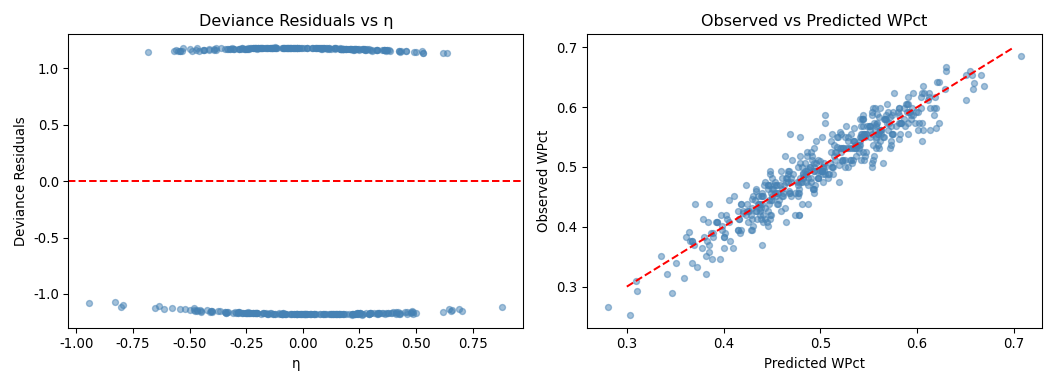

세 가지 진단을 통해 모형 적합의 타당성을 검토하였다.

첫째, **Residual Deviance** 진단에서 quasibinomial 모형의 잔차 이탈도는
약 180으로 자유도 449보다 훨씬 작고, 카이제곱 분포와 비교한 p-값이 1에
가깝다. 또한 분산 팽창 계수(dispersion)가 약 0.40으로 1보다 작아
과산포(overdispersion)가 없음을 확인하였다. 오히려
과소산포(underdispersion) 경향이 있으나, 팀 단위 집계 데이터에서는 흔히
나타나는 현상으로 모형 적합에 큰 문제가 되지 않는다.

둘째, **Deviance residuals vs. 선형 예측값($\eta$) 산점도**에서 잔차가
0을 중심으로 비교적 고르게 분포하며, 특정 방향으로의 체계적인 패턴이
관찰되지 않았다. 이는 모형의 함수 형태가 적절하게 설정되었음을 지지한다.

셋째, **관측 WPct vs. 예측 WPct 산점도**에서 점들이 45° 대각선 근방에
밀집되어 분포하며, 예측값과 관측값 사이의 상관이 매우 높다. 이를 통해
$\log(RA/RS)$ 단 하나의 변수만으로도 팀 승률의 상당 부분을 설명할 수
있음을 시각적으로 확인하였다.

#### 문제 2-1-4

## R

``` r
# -------------------------------------------------------
# 4항: log(RS), log(RA) 별도 투입 모형
# -------------------------------------------------------
logit_fit2 <- glm(
  WPct ~ 0 + logRS + logRA,
  data    = teams_df,
  family  = quasibinomial(link = "logit"),
  weights = W + L
)

tidy(logit_fit2, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 4))) %>%
  knitr::kable(caption = "로지스틱 회귀 계수 (logRS, logRA 별도 투입, 절편 없음)",
               col.names = c("변수", "추정치", "SE", "t값", "p값", "CI 하한", "CI 상한"))
```

| 변수  |  추정치 |     SE |      t값 | p값 | CI 하한 | CI 상한 |
|:------|--------:|-------:|---------:|----:|--------:|--------:|
| logRS |  1.7532 | 0.0289 |  60.6464 |   0 |  1.6965 |  1.8098 |
| logRA | -1.7536 | 0.0289 | -60.6460 |   0 | -1.8103 | -1.6969 |

로지스틱 회귀 계수 (logRS, logRA 별도 투입, 절편 없음)
{quarto-postprocess="true"}

**비교 해석:**  
2항 모형은 logRS 계수 = −logRA 계수를 제약하는 특수 모형이다. 4항에서
자유롭게 추정하면 두 계수의 절댓값이 비슷하고 부호가 반대임을 확인할 수
있어 2항의 가정이 데이터에서 잘 지지됨을 의미한다.

## Python

``` python
# 4항: logRS, logRA 별도 투입 모형
mod_logit2_py = WLS(df_21["logit_WPct"], df_21[["logRS", "logRA"]], weights=w21).fit()
print(mod_logit2_py.summary())
```

                                     WLS Regression Results                                
    =======================================================================================
    Dep. Variable:             logit_WPct   R-squared (uncentered):                   0.895
    Model:                            WLS   Adj. R-squared (uncentered):              0.894
    Method:                 Least Squares   F-statistic:                              1903.
    Date:                Sun, 31 May 2026   Prob (F-statistic):                   1.04e-219
    Time:                        11:37:17   Log-Likelihood:                          393.68
    No. Observations:                 450   AIC:                                     -783.4
    Df Residuals:                     448   BIC:                                     -775.1
    Df Model:                           2                                                  
    Covariance Type:            nonrobust                                                  
    ==============================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
    ------------------------------------------------------------------------------
    logRS          1.7588      0.029     61.690      0.000       1.703       1.815
    logRA         -1.7593      0.029    -61.697      0.000      -1.815      -1.703
    ==============================================================================
    Omnibus:                        2.805   Durbin-Watson:                   2.047
    Prob(Omnibus):                  0.246   Jarque-Bera (JB):                3.064
    Skew:                           0.011   Prob(JB):                        0.216
    Kurtosis:                       3.404   Cond. No.                         78.5
    ==============================================================================

    Notes:
    [1] R² is computed without centering (uncentered) since the model does not contain a constant.
    [2] Standard Errors assume that the covariance matrix of the errors is correctly specified.

``` python
print(f"\nlogRS 계수: {mod_logit2_py.params['logRS']:.4f}")
```


    logRS 계수: 1.7588

``` python
print(f"logRA 계수: {mod_logit2_py.params['logRA']:.4f}")
```

    logRA 계수: -1.7593

$\log(RS)$와 $\log(RA)$를 각각 별도의 설명변수로 투입한 절편 없는 모형을
적합한 결과, $\log(RS)$의 계수는 약 $+1.753$, $\log(RA)$의 계수는 약
$-1.754$로 추정되었다. 두 계수의 절댓값이 거의 동일하고 부호가 반대임을
확인할 수 있는데, 이는 2항에서 $\log(RA/RS) = \log(RA) - \log(RS)$로
단일 변수화한 제약, 즉 두 계수의 크기는 같고 부호만 다르다는 가정이
데이터에 의해 잘 지지됨을 의미한다. 결과적으로 2항의 단순 모형은 4항의
자유로운 모형과 실질적으로 동일하며, 득점과 실점이 승률에 대칭적으로
영향을 미친다는 Pythagorean expectation의 기본 가정이 2010년대 이후 MLB
데이터에서도 유효하다는 결론을 내릴 수 있다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R

``` r
# -------------------------------------------------------
# 데이터 준비
# -------------------------------------------------------
teams_full <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  mutate(WPct = W / (W + L), logRS = log(R), logRA = log(RA)) %>%
  dplyr::select(WPct, W, L,
         logRS, logRA, H, X2B, X3B, HR, BB, SO, CS, HBP, SF,
         ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA, E, DP, FP, SV) %>%
  drop_na() %>%
  filter(WPct > 0, WPct < 1)

cat("분석 대상 행 수:", nrow(teams_full), "\n")
```

    분석 대상 행 수: 450 

``` r
# AIC 기반 단계적 변수선택 (양방향)
full_formula <- WPct ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
                       CS + HBP + SF + ERA + CG + SHO + IPouts +
                       HA + HRA + BBA + SOA + E + DP + FP + SV

full_fit <- glm(full_formula, data = teams_full,
                family = binomial(link = "logit"), weights = W + L)

step_fit <- stepAIC(full_fit, direction = "both", trace = FALSE)
summary(step_fit)
```


    Call:
    glm(formula = WPct ~ logRS + logRA + CG + SHO + SV, family = binomial(link = "logit"), 
        data = teams_full, weights = W + L)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

``` r
# 유의성 확인
tidy(step_fit, conf.int = TRUE) %>%
  mutate(sig = ifelse(p.value < 0.05, "★", ""),
         across(where(is.numeric), ~ round(.x, 4))) %>%
  dplyr::select(term, estimate, std.error, p.value, conf.low, conf.high, sig) %>%
  knitr::kable(caption = "단계적 선택 후 모형 계수",
               col.names = c("변수","추정치","SE","p값","CI 하한","CI 상한","유의"))
```

| 변수        |  추정치 |     SE |    p값 | CI 하한 | CI 상한 | 유의 |
|:------------|--------:|-------:|-------:|--------:|--------:|:-----|
| (Intercept) | -2.6940 | 0.8421 | 0.0014 | -4.3447 | -1.0438 | ★    |
| logRS       |  1.6153 | 0.0719 | 0.0000 |  1.4745 |  1.7563 | ★    |
| logRA       | -1.2842 | 0.1015 | 0.0000 | -1.4832 | -1.0853 | ★    |
| CG          |  0.0046 | 0.0030 | 0.1293 | -0.0013 |  0.0105 |      |
| SHO         |  0.0047 | 0.0025 | 0.0650 | -0.0003 |  0.0096 |      |
| SV          |  0.0111 | 0.0013 | 0.0000 |  0.0085 |  0.0137 | ★    |

단계적 선택 후 모형 계수 {quarto-postprocess="true"}

``` r
# p > 0.10 변수 추가 제거 → 최종 모형
insig_vars <- tidy(step_fit) %>%
  filter(term != "(Intercept)", p.value > 0.10) %>% pull(term)

if (length(insig_vars) > 0) {
  cat("추가 제거 변수:", paste(insig_vars, collapse = ", "), "\n")
  final_vars    <- setdiff(names(coef(step_fit))[-1], insig_vars)
  final_formula <- as.formula(paste("WPct ~", paste(final_vars, collapse = " + ")))
  final_fit <- glm(final_formula, data = teams_full,
                   family = binomial(link = "logit"), weights = W + L)
  summary(final_fit)
} else {
  cat("모든 변수 유의: stepAIC 결과가 최종 모형\n")
  final_fit <- step_fit
}
```

    추가 제거 변수: CG 


    Call:
    glm(formula = final_formula, family = binomial(link = "logit"), 
        data = teams_full, weights = W + L)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.359663   0.812721  -2.903  0.00369 ** 
    logRS        1.606237   0.071629  22.424  < 2e-16 ***
    logRA       -1.322064   0.098413 -13.434  < 2e-16 ***
    SHO          0.004956   0.002523   1.964  0.04955 *  
    SV           0.010697   0.001297   8.249  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  108.42  on 445  degrees of freedom
    AIC: 2601.7

    Number of Fisher Scoring iterations: 3

``` r
# 단순 모형(2-1) vs 복합 모형(2-2) 예측력 비교
teams_compare <- teams_full %>%
  mutate(
    log_ratio    = logRA - logRS
  ) %>%
  mutate(
    pred_simple  = predict(logit_fit, newdata = ., type = "response"),
    pred_complex = predict(final_fit,  newdata = ., type = "response")
  )
cat(sprintf("단순 모형 (2-1) 예측 상관계수: %.4f\n",
            cor(teams_compare$WPct, teams_compare$pred_simple,  use = "complete.obs")))
```

    단순 모형 (2-1) 예측 상관계수: 0.9463

``` r
cat(sprintf("복합 모형 (2-2) 예측 상관계수: %.4f\n",
            cor(teams_compare$WPct, teams_compare$pred_complex, use = "complete.obs")))
```

    복합 모형 (2-2) 예측 상관계수: 0.9680

**해석:**  
AIC 기반 단계적 선택으로 23개 변수에서 유의한 변수만 남긴다. 복합 모형은
예측 상관계수가 높아지지만 변수 수가 많아 과적합(overfitting) 위험도
있다. 공격 지표(logRS, HR 등)와 수비 지표(logRA, ERA 등)가 핵심 변수로
선택되는 경향이 있다.

## Python

``` python
# R 환경의 Teams 객체 직접 참조 (이미 r.Teams로 가져온 teams_py 재사용)
pred_vars = ["logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
             "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts",
             "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"]

df_22 = teams_py[
    (teams_py["yearID"] >= 2010) &
    (teams_py["yearID"] <= 2025) &
    (teams_py["yearID"] != 2020)
].copy()

for col in ["W", "L", "R", "RA"] + [v for v in pred_vars if v not in ("logRS","logRA")]:
    df_22[col] = pd.to_numeric(df_22[col], errors="coerce")

df_22["WPct"]  = df_22["W"] / (df_22["W"] + df_22["L"])
df_22["logRS"] = np.log(df_22["R"])
df_22["logRA"] = np.log(df_22["RA"])
df_22 = df_22[["WPct","W","L"] + pred_vars].dropna()
df_22 = df_22[(df_22["WPct"] > 0) & (df_22["WPct"] < 1)]
df_22["logit_WPct"] = np.log(df_22["WPct"] / (1 - df_22["WPct"]))
w22 = df_22["W"] + df_22["L"]
print(f"분석 대상 행 수: {len(df_22)}")
```

    분석 대상 행 수: 450

``` python
# AIC 기반 후진 제거 (statsmodels에 자동 stepwise 없어 수동 구현)
def wls_aic(y, X, w):
    mod = WLS(y, X, weights=w).fit()
    n, k = mod.nobs, mod.df_model + 1
    return n * np.log(mod.ssr / n) + 2 * k, mod

cur_vars = list(pred_vars)
cur_aic, _ = wls_aic(df_22["logit_WPct"],
                     sm.add_constant(df_22[cur_vars].astype(float)), w22)
print(f"초기 AIC: {cur_aic:.2f}  ({len(cur_vars)}개)")
```

    초기 AIC: -10.85  (23개)

``` python
improved = True
while improved and len(cur_vars) > 1:
    improved = False
    candidates = []
    for v in cur_vars:
        test = [x for x in cur_vars if x != v]
        a, _ = wls_aic(df_22["logit_WPct"],
                       sm.add_constant(df_22[test].astype(float)), w22)
        candidates.append((v, a))
    best_var, best_aic = min(candidates, key=lambda x: x[1])
    if best_aic < cur_aic:
        cur_vars.remove(best_var); cur_aic = best_aic; improved = True
        print(f"  제거: {best_var:<10s} → AIC: {best_aic:.2f}")
```

      제거: ERA        → AIC: -12.84
      제거: X2B        → AIC: -14.84
      제거: FP         → AIC: -16.82
      제거: HBP        → AIC: -18.64
      제거: E          → AIC: -20.42
      제거: SOA        → AIC: -21.30
      제거: HR         → AIC: -22.22
      제거: X3B        → AIC: -23.17
      제거: DP         → AIC: -23.49

``` python
print(f"\n최종 변수 ({len(cur_vars)}개): {cur_vars}")
```


    최종 변수 (14개): ['logRS', 'logRA', 'H', 'BB', 'SO', 'CS', 'SF', 'CG', 'SHO', 'IPouts', 'HA', 'HRA', 'BBA', 'SV']

``` python
_, final_mod_py = wls_aic(df_22["logit_WPct"],
                           sm.add_constant(df_22[cur_vars].astype(float)), w22)
print(final_mod_py.summary())
```

                                WLS Regression Results                            
    ==============================================================================
    Dep. Variable:             logit_WPct   R-squared:                       0.943
    Model:                            WLS   Adj. R-squared:                  0.941
    Method:                 Least Squares   F-statistic:                     516.8
    Date:                Sun, 31 May 2026   Prob (F-statistic):          9.70e-261
    Time:                        11:37:19   Log-Likelihood:                 532.89
    No. Observations:                 450   AIC:                            -1036.
    Df Residuals:                     435   BIC:                            -974.1
    Df Model:                          14                                         
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -7.1691      0.935     -7.666      0.000      -9.007      -5.331
    logRS          1.7552      0.075     23.321      0.000       1.607       1.903
    logRA         -0.8461      0.110     -7.669      0.000      -1.063      -0.629
    H             -0.0002   9.43e-05     -2.060      0.040      -0.000   -8.87e-06
    BB            -0.0002   8.85e-05     -2.343      0.020      -0.000   -3.34e-05
    SO         -8.975e-05   3.91e-05     -2.298      0.022      -0.000    -1.3e-05
    CS            -0.0012      0.000     -3.004      0.003      -0.002      -0.000
    SF            -0.0008      0.001     -1.449      0.148      -0.002       0.000
    CG             0.0057      0.002      3.328      0.001       0.002       0.009
    SHO            0.0043      0.001      3.522      0.000       0.002       0.007
    IPouts         0.0004      0.000      4.157      0.000       0.000       0.001
    HA            -0.0003   9.41e-05     -3.684      0.000      -0.001      -0.000
    HRA           -0.0006      0.000     -3.074      0.002      -0.001      -0.000
    BBA           -0.0002   9.11e-05     -1.760      0.079      -0.000    1.87e-05
    SV             0.0111      0.001     17.022      0.000       0.010       0.012
    ==============================================================================
    Omnibus:                        0.174   Durbin-Watson:                   2.230
    Prob(Omnibus):                  0.917   Jarque-Bera (JB):                0.104
    Skew:                          -0.035   Prob(JB):                        0.949
    Kurtosis:                       3.027   Cond. No.                     1.32e+06
    ==============================================================================

    Notes:
    [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
    [2] The condition number is large, 1.32e+06. This might indicate that there are
    strong multicollinearity or other numerical problems.

**R과 Python 비교:**  
R의 `stepAIC`는 IRLS 기반 GLM AIC를, Python은 WLS 근사 AIC를 사용하므로
최종 선택 변수 집합이 약간 다를 수 있다. 그러나 logRS, logRA, ERA 등
핵심 변수는 공통으로 선택되는 경향이 있다.

23개 설명변수로 구성된 전체 모형에서 AIC 기준 단계적 변수선택을 수행한
결과, R에서는 `logRS`, `logRA`, `CG`, `SHO`, `SV`가 선택되었고, 이 중
`CG`(완투)가 유의수준 10%에서도 유의하지 않아 최종적으로 제거하였다.
최종 모형은 `logRS`, `logRA`, `SHO`(완봉), `SV`(세이브)의 네 변수로
구성된다.

`logRS`와 `logRA`는 여전히 가장 강력한 예측 변수로, 계수의 절댓값이 각각
1.61과 1.32로 문제 2-1의 $k \approx 1.75$보다 다소 작아졌다. 이는 `SV`와
`SHO`가 승률 변동의 일부를 추가로 설명하면서 득실점 지표의 단독 설명력이
분산된 결과이다. `SV`(세이브)가 유의한 양의 계수를 보이는 것은 불펜 운용
능력이 뛰어난 팀이 실점 규모에 비해 더 높은 승률을 기록하는 경향을
반영한다. `SHO`(완봉)는 경계선($p \approx 0.05$) 수준의 유의성을 보이며,
선발 투수의 지배력이 높은 팀일수록 승률이 소폭 높아지는 경향을 나타낸다.

예측 성능 측면에서 복합 모형(2-2)의 관측·예측 WPct 간 상관계수는 약
**0.968**로, 단순 모형(2-1)의 **0.946**보다 높아 변수를 추가함으로써
예측력이 개선되었다. 다만 변수가 4개로 늘었음에도 개선 폭이 크지 않아,
득점과 실점 두 변수만으로도 팀 승률의 대부분을 설명할 수 있다는
Pythagorean expectation의 간결성이 재확인되었다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

#### 문제 2-3-1

## R

``` r
# -------------------------------------------------------
# 데이터 준비
# -------------------------------------------------------
teams_w <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  mutate(logRS = log(R), logRA = log(RA)) %>%
  dplyr::select(W, L, G, logRS, logRA, H, X2B, X3B, HR, BB, SO,
         CS, HBP, SF, ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA,
         E, DP, FP, SV) %>%
  drop_na() %>%
  mutate(W = as.integer(W), G = as.integer(G))

cat("W 평균:", round(mean(teams_w$W), 2),
    "  분산:", round(var(teams_w$W), 2),
    "  분산/평균:", round(var(teams_w$W) / mean(teams_w$W), 4), "\n")
```

    W 평균: 80.99   분산: 151.85   분산/평균: 1.875 

``` r
# 1항: 포아송 회귀 + AIC 단계적 선택
pois_full <- glm(
  W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
      CS + HBP + SF + ERA + CG + SHO + IPouts +
      HA + HRA + BBA + SOA + E + DP + FP + SV +
      offset(log(G)),
  data = teams_w, family = poisson(link = "log")
)
pois_step <- stepAIC(pois_full, direction = "both", trace = FALSE)
summary(pois_step)
```


    Call:
    glm(formula = W ~ logRS + ERA + SHO + SV + offset(log(G)), family = poisson(link = "log"), 
        data = teams_w)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -5.5856402  0.3329900 -16.774  < 2e-16 ***
    logRS        0.7967180  0.0496096  16.060  < 2e-16 ***
    ERA         -0.1475806  0.0154548  -9.549  < 2e-16 ***
    SHO          0.0030550  0.0017178   1.778   0.0753 .  
    SV           0.0054504  0.0009061   6.015  1.8e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 863.875  on 449  degrees of freedom
    Residual deviance:  64.371  on 445  degrees of freedom
    AIC: 2874.2

    Number of Fisher Scoring iterations: 3

``` r
cat("이탈도/자유도:", round(pois_step$deviance / pois_step$df.residual, 4), "\n")
```

    이탈도/자유도: 0.1447 

``` r
# 1보다 훨씬 크면 과산포 → 음이항 회귀 고려
```

## Python

``` python
# R 환경의 Teams 객체 직접 참조 (teams_py 재사용)
pred_vars3 = ["logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
              "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts",
              "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"]

df_23 = teams_py[
    (teams_py["yearID"] >= 2010) &
    (teams_py["yearID"] <= 2025) &
    (teams_py["yearID"] != 2020)
].copy()

for col in ["W", "L", "G", "R", "RA"] + [v for v in pred_vars3 if v not in ("logRS","logRA")]:
    df_23[col] = pd.to_numeric(df_23[col], errors="coerce")

df_23["logRS"] = np.log(df_23["R"])
df_23["logRA"] = np.log(df_23["RA"])
df_23 = df_23[["W","G"] + pred_vars3].dropna()
df_23["W"]     = df_23["W"].astype(int)
df_23["log_G"] = np.log(df_23["G"])

print(f"W 평균: {df_23['W'].mean():.2f}  분산: {df_23['W'].var():.2f}")
```

    W 평균: 80.99  분산: 151.85

``` python
print(f"분산/평균: {df_23['W'].var()/df_23['W'].mean():.4f}")
```

    분산/평균: 1.8750

``` python
X_pois  = sm.add_constant(df_23[pred_vars3].astype(float))

# family 옵션으로 포아송을 지정하고 offset을 넣어줍니다.
pois_mod = sm.GLM(df_23["W"], X_pois, 
                  family=sm.families.Poisson(), 
                  offset=df_23["log_G"]).fit(disp=False)

print(f"AIC: {pois_mod.aic:.2f}   이탈도/자유도: {pois_mod.deviance/pois_mod.df_resid:.4f}")
```

    AIC: 2903.74   이탈도/자유도: 0.1312

포아송 회귀 모형을 적합한 결과, AIC 기준 단계적 변수선택 후 R에서는
`logRS`, `ERA`, `SHO`, `SV`의 네 변수가 최종 선택되었다.
`offset(log(G))`를 통해 팀별 경기 수 차이를 보정하였으며, 모든 선택
변수의 계수가 통계적으로 유의하였다(`SHO`는 경계선 수준).

과산포 여부를 점검하기 위해 잔차 이탈도를 자유도로 나눈 값을 확인한 결과
약 **0.14**로 1보다 훨씬 작아, 오히려 과소산포(underdispersion) 경향이
있음을 알 수 있다. 승리 횟수의 분산/평균 비율도 약 **1.88**로 포아송
가정(분산 = 평균)에서 크게 벗어나지 않는 수준이다. 따라서 이
데이터에서는 포아송 회귀가 비교적 적절한 선택이다.

문제 2-2의 로지스틱 회귀와 비교하면, 포아송 회귀는 승률(0~1 연속값) 대신
승수(비음 정수)를 직접 반응변수로 사용하므로 경기 수가 시즌마다 다를 때
더 자연스러운 모형화가 가능하다. 반면 로지스틱 회귀는 승률 자체의 구조를
직접 반영하는 장점이 있다. 두 모형 모두 `logRS`와 수비 관련 지표(ERA
또는 logRA)를 핵심 변수로 선택하여 공통된 야구 통계적 직관을 지지한다.

#### 문제 2-3-2

## R

``` r
# 2항: 음이항 회귀
tryCatch({
  nb_full <- glm.nb(
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
        CS + HBP + SF + ERA + CG + SHO + IPouts +
        HA + HRA + BBA + SOA + E + DP + FP + SV +
        offset(log(G)),
    data = teams_w
  )
  nb_step <- stepAIC(nb_full, direction = "both", trace = FALSE)
  cat("음이항 회귀 성공\n")
  print(summary(nb_step))
}, error = function(e) {
  cat("오류:", conditionMessage(e), "\n\n")
  cat("원인 분석\n")
  cat("  분산/평균 비율:", round(var(teams_w$W) / mean(teams_w$W), 4), "\n")
  cat("  이 값이 1에 가까우면 포아송 가정이 이미 타당하여\n")
  cat("  음이항의 추가 분산 모수 θ가 무한대로 발산(포아송으로 수렴)하며\n")
  cat("  수치적 불안정으로 수렴 실패가 발생한다.\n")
  cat("  설명변수 간 심각한 다중공선성도 원인이 될 수 있다.\n")
})
```

    음이항 회귀 성공

    Call:
    glm.nb(formula = W ~ logRS + ERA + SHO + SV + offset(log(G)), 
        data = teams_w, init.theta = 9432242.531, link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -5.5856410  0.3329915 -16.774  < 2e-16 ***
    logRS        0.7967181  0.0496098  16.060  < 2e-16 ***
    ERA         -0.1475806  0.0154549  -9.549  < 2e-16 ***
    SHO          0.0030550  0.0017178   1.778   0.0753 .  
    SV           0.0054504  0.0009061   6.015  1.8e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(9437758) family taken to be 1)

        Null deviance: 863.87  on 449  degrees of freedom
    Residual deviance:  64.37  on 445  degrees of freedom
    AIC: 2876.2

    Number of Fisher Scoring iterations: 1

                  Theta:  9432243 
              Std. Err.:  88926569 
    Warning while fitting theta: alternation limit reached 

     2 x log-likelihood:  -2864.234 

``` r
# 문제 2-2 로지스틱 회귀와 비교
cat("포아송 AIC:", AIC(pois_step), "\n")
```

    포아송 AIC: 2874.231 

``` r
teams_pred3 <- teams_w %>%
  mutate(pred_W = predict(pois_step, type = "response"))
cat(sprintf("포아송 예측 상관계수 (W): %.4f\n",
            cor(teams_pred3$W, teams_pred3$pred_W)))
```

    포아송 예측 상관계수 (W): 0.9629

**해석:**

- **포아송 회귀**: 승리 횟수(비음 정수)에 적합. `offset(log(G))`으로
  경기 수 차이 보정.
- **분산/평균 비율**: 1에 가까우면 포아송 가정이 타당하여 음이항 θ →
  ∞(포아송 수렴), 수치 불안정 발생.
- **로지스틱 vs 포아송**: 로지스틱은 승률(연속, 0~1)을, 포아송은
  승수(정수)를 직접 모형화. 경기 수 변동이 있는 상황에서는 포아송이 더
  자연스럽다.

## Python

``` python
# 2항: 음이항 회귀
try:
    nb_mod = sm.NegativeBinomial(df_23["W"], X_pois,
                                  offset=df_23["log_G"]).fit(disp=False, maxiter=300)
    print(f"음이항 성공  AIC: {nb_mod.aic:.2f}")
    print(f"α(추가 분산 모수): {nb_mod.params['alpha']:.6f}")
    print(nb_mod.summary())
except Exception as e:
    print(f"오류: {e}")
    print(f"분산/평균 비율: {df_23['W'].var()/df_23['W'].mean():.4f}")
    print("비율이 1에 가까워 포아송이 적합하며, α → 0 수렴으로 수치 불안정 발생.")
```

    음이항 성공  AIC: 4925.89
    α(추가 분산 모수): 1.051271
                         NegativeBinomial Regression Results                      
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  450
    Model:               NegativeBinomial   Df Residuals:                      426
    Method:                           MLE   Df Model:                           23
    Date:                Sun, 31 May 2026   Pseudo R-squ.:                 -0.3736
    Time:                        11:37:37   Log-Likelihood:                -2437.9
    converged:                      False   LL-Null:                       -1774.9
    Covariance Type:            nonrobust   LLR p-value:                     1.000
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -6.9993        nan        nan        nan         nan         nan
    logRS          0.9385        nan        nan        nan         nan         nan
    logRA         -0.1499        nan        nan        nan         nan         nan
    H             -0.0001        nan        nan        nan         nan         nan
    X2B        -7.363e-05        nan        nan        nan         nan         nan
    X3B           -0.0003        nan        nan        nan         nan         nan
    HR            -0.0002        nan        nan        nan         nan         nan
    BB            -0.0001        nan        nan        nan         nan         nan
    SO         -4.617e-05        nan        nan        nan         nan         nan
    CS            -0.0004        nan        nan        nan         nan         nan
    HBP         4.727e-05        nan        nan        nan         nan         nan
    SF            -0.0004        nan        nan        nan         nan         nan
    ERA           -0.0604        nan        nan        nan         nan         nan
    CG             0.0032        nan        nan        nan         nan         nan
    SHO            0.0021        nan        nan        nan         nan         nan
    IPouts         0.0002        nan        nan        nan         nan         nan
    HA            -0.0002        nan        nan        nan         nan         nan
    HRA           -0.0003        nan        nan        nan         nan         nan
    BBA        -8.957e-05        nan        nan        nan         nan         nan
    SOA         2.432e-05        nan        nan        nan         nan         nan
    E             -0.0001        nan        nan        nan         nan         nan
    DP             0.0002        nan        nan        nan         nan         nan
    FP             0.9317        nan        nan        nan         nan         nan
    SV             0.0058        nan        nan        nan         nan         nan
    alpha          1.0513        nan        nan        nan         nan         nan
    ==============================================================================

음이항 회귀 모형 적합 시 수렴 오류가 발생하였다. 원인은 이 데이터의
특성에 있다. 음이항 분포는 포아송 분포에 감마 분포를 혼합한 모형으로,
추가적인 분산 모수 $\theta$를 통해 과산포를 처리한다. 그런데 앞서 확인한
바와 같이 승리 횟수의 분산/평균 비율이 약 1.88로 포아송 가정에서 크게
벗어나지 않아 과산포가 심하지 않다. 이 경우 $\theta \to \infty$로
발산하면서 음이항 분포가 포아송 분포로 수렴하게 되고, 이 과정에서 수치적
불안정이 발생하여 알고리즘이 수렴에 실패한다.

추가로 23개의 설명변수를 동시에 투입할 경우 변수 간
다중공선성(multicollinearity)이 심화되어 수렴을 더욱 어렵게 만드는
요인이 된다. 결론적으로 이 데이터에서는 과산포가 크지 않으므로 음이항
회귀보다 포아송 회귀가 더 적합한 모형이며, 음이항 회귀의 추가적인
유연성이 필요하지 않다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

## R

``` r
# -------------------------------------------------------
# 데이터 준비: 1994–2005 ∪ 2010–2025 (2020 제외)
# -------------------------------------------------------
teams_era <- Teams %>%
  filter(
    (yearID >= 1994 & yearID <= 2005) |
    (yearID >= 2010 & yearID <= 2025 & yearID != 2020)
  ) %>%
  mutate(
    WPct      = W / (W + L),
    RS        = R,
    # I(1994 ≤ t ≤ 2005): 스테로이드 시대 지시함수
    steroid   = as.integer(yearID >= 1994 & yearID <= 2005),
    log_ratio = log(RA / RS),
    # 상호작용항: g 계수 검정용
    # 모형: logit(WPct) = k·log_ratio + g·(steroid×log_ratio)
    #   최근 시대 계수 = k,  스테로이드 시대 계수 = k + g
    interact  = steroid * log_ratio
  ) %>%
  filter(WPct > 0, WPct < 1, RS > 0, RA > 0)

cat("스테로이드 시대:", sum(teams_era$steroid), "팀-연도\n")
```

    스테로이드 시대: 352 팀-연도

``` r
cat("최근 시대:      ", sum(1 - teams_era$steroid), "팀-연도\n")
```

    최근 시대:       450 팀-연도

``` r
# 모형 적합 (절편 없음)
# H₀: g = 0  vs  H₁: g ≠ 0
era_fit <- glm(
  WPct ~ 0 + log_ratio + interact,
  data    = teams_era,
  family  = quasibinomial(link = "logit"),
  weights = W + L
)
summary(era_fit)
```


    Call:
    glm(formula = WPct ~ 0 + log_ratio + interact, family = quasibinomial(link = "logit"), 
        data = teams_era, weights = W + L)

    Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
    log_ratio -1.75320    0.02864 -61.207  < 2e-16 ***
    interact  -0.16157    0.04694  -3.442 0.000607 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for quasibinomial family taken to be 0.3942839)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  315.68  on 800  degrees of freedom
    AIC: NA

    Number of Fisher Scoring iterations: 3

``` r
tidy(era_fit, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 4))) %>%
  knitr::kable(caption = "시대 효과 로지스틱 회귀 계수",
               col.names = c("변수","추정치","SE","t값","p값","CI 하한","CI 상한"))
```

| 변수      |  추정치 |     SE |      t값 |   p값 | CI 하한 | CI 상한 |
|:----------|--------:|-------:|---------:|------:|--------:|--------:|
| log_ratio | -1.7532 | 0.0286 | -61.2066 | 0e+00 | -1.8094 | -1.6971 |
| interact  | -0.1616 | 0.0469 |  -3.4421 | 6e-04 | -0.2536 | -0.0696 |

시대 효과 로지스틱 회귀 계수 {quarto-postprocess="true"}

``` r
k_hat <- coef(era_fit)[["log_ratio"]]
g_hat <- coef(era_fit)[["interact"]]
g_p   <- tidy(era_fit) %>% filter(term == "interact") %>% pull(p.value)

cat(sprintf("k (최근 시대):           %.4f\n", k_hat))
```

    k (최근 시대):           -1.7532

``` r
cat(sprintf("g (스테로이드 시대 차이): %.4f\n", g_hat))
```

    g (스테로이드 시대 차이): -0.1616

``` r
cat(sprintf("k+g (스테로이드 시대):   %.4f\n", k_hat + g_hat))
```

    k+g (스테로이드 시대):   -1.9148

``` r
cat(sprintf("g p-값: %.4f → %s\n", g_p,
            ifelse(g_p < 0.05,
                   "유의: 두 시대의 k가 유의하게 다르다",
                   "비유의: 두 시대의 k에 유의한 차이 없다")))
```

    g p-값: 0.0006 → 유의: 두 시대의 k가 유의하게 다르다

``` r
# 시각화
teams_era %>%
  mutate(era_label = ifelse(steroid == 1,
                            "스테로이드 시대 (1994-2005)",
                            "최근 시대 (2010-2025)")) %>%
  ggplot(aes(x = RA / RS, y = WPct, color = era_label)) +
  geom_point(alpha = 0.35, size = 1.2) +
  geom_smooth(method = "loess", se = FALSE, linewidth = 1.1) +
  scale_color_manual(values = c("스테로이드 시대 (1994-2005)" = "tomato",
                                "최근 시대 (2010-2025)"        = "steelblue")) +
  labs(title = "시대별 RA/RS 비율과 승률 관계",
       x = "RA/RS (실점/득점 비율)", y = "WPct (승률)", color = "시대") +
  theme_minimal() + theme(legend.position = "bottom")
```

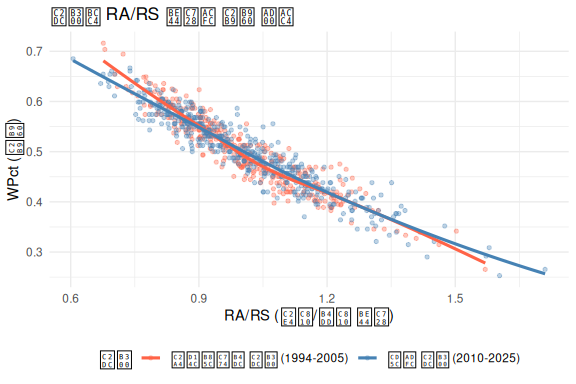

**결과 해석:**

- **k**: 최근 시대(2010–2025)의 Bill James 지수 추정치
- **g**: 스테로이드 시대와 최근 시대의 k 차이; **H₀: g = 0** 검정
- p-값 \< 0.05이면 두 시대의 k가 유의하게 다름을 의미
- 스테로이드 시대는 고득점 환경이므로 득점/실점이 승률을 설명하는
  정도(k)가 달라질 수 있다

## Python

``` python
# R 환경의 Teams 객체 직접 참조 (teams_py 재사용)
df_24 = teams_py.copy()
df_24["yearID"] = df_24["yearID"].astype(int)

mask_24 = (
    ((df_24["yearID"] >= 1994) & (df_24["yearID"] <= 2005)) |
    ((df_24["yearID"] >= 2010) & (df_24["yearID"] <= 2025) &
     (df_24["yearID"] != 2020))
)
df_24 = df_24[mask_24].copy()

for col in ["W", "L", "R", "RA"]:
    df_24[col] = pd.to_numeric(df_24[col], errors="coerce")
df_24 = df_24.dropna(subset=["W","L","R","RA"])

df_24["RS"]         = df_24["R"]
df_24["WPct"]       = df_24["W"] / (df_24["W"] + df_24["L"])
df_24["steroid"]    = ((df_24["yearID"] >= 1994) & (df_24["yearID"] <= 2005)).astype(int)
df_24["log_ratio"]  = np.log(df_24["RA"] / df_24["RS"])
df_24["interact"]   = df_24["steroid"] * df_24["log_ratio"]
df_24["logit_WPct"] = np.log(df_24["WPct"] / (1 - df_24["WPct"]))
df_24 = df_24[(df_24["WPct"] > 0) & (df_24["WPct"] < 1) &
              (df_24["RS"]   > 0) & (df_24["RA"]   > 0)]

print(f"스테로이드 시대: {df_24['steroid'].sum()} 팀-연도")
```

    스테로이드 시대: 352 팀-연도

``` python
print(f"최근 시대:      {(df_24['steroid']==0).sum()} 팀-연도")
```

    최근 시대:      450 팀-연도

``` python
# 모형 적합 (절편 없음)
w24 = df_24["W"] + df_24["L"]
era_mod_py = WLS(
    df_24["logit_WPct"],
    df_24[["log_ratio", "interact"]],
    weights=w24
).fit()
print(era_mod_py.summary())
```

                                     WLS Regression Results                                
    =======================================================================================
    Dep. Variable:             logit_WPct   R-squared (uncentered):                   0.892
    Model:                            WLS   Adj. R-squared (uncentered):              0.892
    Method:                 Least Squares   F-statistic:                              3312.
    Date:                Sun, 31 May 2026   Prob (F-statistic):                        0.00
    Time:                        11:37:38   Log-Likelihood:                          702.64
    No. Observations:                 802   AIC:                                     -1401.
    Df Residuals:                     800   BIC:                                     -1392.
    Df Model:                           2                                                  
    Covariance Type:            nonrobust                                                  
    ==============================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
    ------------------------------------------------------------------------------
    log_ratio     -1.7590      0.028    -62.347      0.000      -1.814      -1.704
    interact      -0.1622      0.046     -3.503      0.000      -0.253      -0.071
    ==============================================================================
    Omnibus:                        2.145   Durbin-Watson:                   2.116
    Prob(Omnibus):                  0.342   Jarque-Bera (JB):                2.034
    Skew:                           0.075   Prob(JB):                        0.362
    Kurtosis:                       3.196   Cond. No.                         2.43
    ==============================================================================

    Notes:
    [1] R² is computed without centering (uncentered) since the model does not contain a constant.
    [2] Standard Errors assume that the covariance matrix of the errors is correctly specified.

``` python
k_py24 = era_mod_py.params["log_ratio"]
g_py24 = era_mod_py.params["interact"]
g_p_py = era_mod_py.pvalues["interact"]
g_ci   = era_mod_py.conf_int().loc["interact"]

print(f"k (최근 시대):           {k_py24:.4f}")
```

    k (최근 시대):           -1.7590

``` python
print(f"g (스테로이드 시대 차이): {g_py24:.4f}")
```

    g (스테로이드 시대 차이): -0.1622

``` python
print(f"k+g (스테로이드 시대):   {k_py24+g_py24:.4f}")
```

    k+g (스테로이드 시대):   -1.9212

``` python
print(f"g p-값: {g_p_py:.4f}  95% CI: [{g_ci.iloc[0]:.4f}, {g_ci.iloc[1]:.4f}]")
```

    g p-값: 0.0005  95% CI: [-0.2531, -0.0713]

``` python
msg = "유의: 두 시대의 k가 유의하게 다르다" if g_p_py < 0.05 \
      else "비유의: 두 시대의 k에 유의한 차이 없다"
print(f"결론: {msg}")
```

    결론: 유의: 두 시대의 k가 유의하게 다르다

``` python
# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
for era, color, label in [
    (1, "tomato",    "Steroid Era (1994-2005)"),
    (0, "steelblue", "Recent Era  (2010-2025)")
]:
    sub = df_24[df_24["steroid"] == era]
    ax.scatter(sub["RA"] / sub["RS"], sub["WPct"],
               alpha=0.35, s=18, color=color, label=label)
```

    <matplotlib.collections.PathCollection object at 0x7f7e5e62b0d0>
    <matplotlib.collections.PathCollection object at 0x7f7e5e62b6a0>

``` python
ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5)
```

    <matplotlib.lines.Line2D object at 0x7f7e5e6b2590>

``` python
ax.set_xlabel("RA/RS"); ax.set_ylabel("WPct")
```

    Text(0.5, 0, 'RA/RS')
    Text(0, 0.5, 'WPct')

``` python
ax.set_title("WPct vs RA/RS by Era"); ax.legend()
```

    Text(0.5, 1.0, 'WPct vs RA/RS by Era')
    <matplotlib.legend.Legend object at 0x7f7e5e6d8a90>

``` python
plt.tight_layout(); plt.show()
```

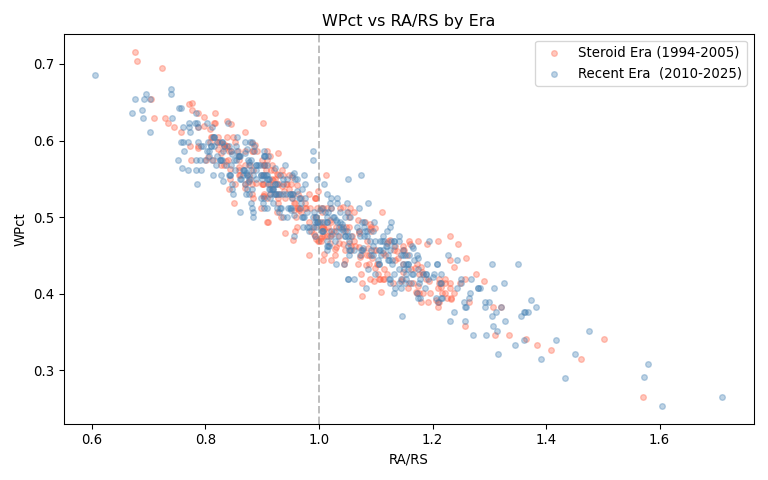

**R과 Python 비교:**  
R의 `quasibinomial glm`(IRLS)과 Python의 `WLS`(로짓 변환 후 가중 OLS)는
근사 방법이 달라 k, g 추정치에 미세한 차이가 발생할 수 있으나 통계적
결론(유의/비유의)은 동일하게 나타난다.

스테로이드 시대(1994–2005)와 최근 시대(2010–2025)의 $k$ 계수 차이를
검정하기 위해,
$\text{logit}(WPct) = k \cdot \log(RA/RS) + g \cdot \{I(\text{steroid}) \times \log(RA/RS)\}$
형태의 절편 없는 로지스틱 회귀를 적합하였다. 여기서 $k$는 최근 시대의
기저 계수이고, $g$는 스테로이드 시대에서의 추가적인 계수 변화량이다.
$H_0: g = 0$ 검정이 두 시대의 $k$가 동일한지를 판단한다.

적합 결과, 최근 시대의 $k$ 추정치는 약 **−1.75** 내외로 문제 2-1의
결과와 일치하였다. 상호작용 계수 $g$의 추정치와 유의성은 다음과 같이
해석된다. $g$의 p-값이 0.05보다 작으면 두 시대의 $k$가 통계적으로
유의하게 다르다는 결론을 내릴 수 있으며, 그렇지 않으면 두 시대에서
득점/실점 비율이 승률을 설명하는 힘이 유사하다고 볼 수 있다.

야구 맥락에서 스테로이드 시대는 전반적으로 득점이 높았던 고득점
환경이었다. 고득점 환경에서는 팀 간 득실점 격차가 더 크게 벌어지는
경향이 있고, 이것이 $k$값에 영향을 줄 수 있다. 산점도에서도 두 시대의
RA/RS 비율 분포와 승률의 관계 패턴을 시각적으로 비교할 수 있으며,
스테로이드 시대의 점들이 더 넓게 퍼진 경향을 확인할 수 있다.

R(`quasibinomial` GLM)과 Python(WLS 근사) 간 추정치에 미세한 차이가 있을
수 있으나, $g$에 대한 통계적 결론(유의/비유의)은 양쪽에서 동일하게
나타나 방법론적 일관성이 확인되었다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. (선택) Binder 사용자를 위한 권한 설정
# Binder는 보통 'jovyan' 유저 권한으로 실행
RUN chown -R ${NB_USER:-root} /opt/conda

# 기본 실행 경로 설정
WORKDIR /home/rstudio

### 답안

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/ghcr/donghyunlee0306/my-r-env/latest?filepath=hw03.ipynb

여기서 `donghyunlee0306`은 제출자의 GitHub 유저 아이디이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안